## Prédiction du risque de démission (XGBoost + SHAP)

## 1. Imports & configuration

In [1]:
import pandas as pd
import numpy as np
import random
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

## 2. Chargement & exploration du dataset

In [2]:
df = pd.read_csv('dataset/HRDataset_v14.csv')
print(f'Shape : {df.shape}')
df.head(3)

Shape : (311, 36)


,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3


In [3]:
df.columns

Index(['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID',
       'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID',
       'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB',
       'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc',
       'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus',
       'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource',
       'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction',
       'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30',
       'Absences'],
      dtype='str')

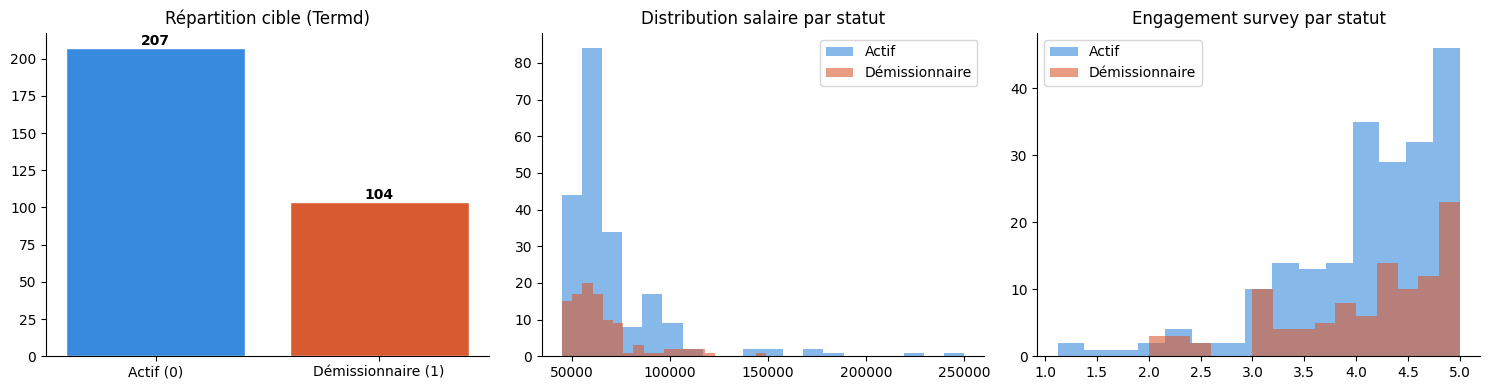


Taux de démission : 33.4%
Raisons de départ principales :
TermReason
Another position          20
unhappy                   14
more money                11
career change              9
hours                      8
attendance                 7
return to school           5
relocation out of area     5


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

counts = df['Termd'].value_counts()
axes[0].bar(['Actif (0)', 'Démissionnaire (1)'], counts.values,
            color=['#378ADD', '#D85A30'], edgecolor='white')
axes[0].set_title('Répartition cible (Termd)')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

for val, color, label in [(0,'#378ADD','Actif'), (1,'#D85A30','Démissionnaire')]:
    axes[1].hist(df[df['Termd']==val]['Salary'], bins=20,
                 alpha=0.6, color=color, label=label)
axes[1].set_title('Distribution salaire par statut')
axes[1].legend()

for val, color, label in [(0,'#378ADD','Actif'), (1,'#D85A30','Démissionnaire')]:
    axes[2].hist(df[df['Termd']==val]['EngagementSurvey'], bins=15,
                 alpha=0.6, color=color, label=label)
axes[2].set_title('Engagement survey par statut')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"\nTaux de démission : {df['Termd'].mean():.1%}")
print(f"Raisons de départ principales :")
print(df[df['Termd']==1]['TermReason'].value_counts().head(8).to_string())

## 3. Enrichissement — textes simulés (sans API)

In [6]:
EXIT_TEMPLATES = {
    'more money': [
        'I genuinely enjoyed my team, but the compensation gap became impossible to ignore after {yrs} years without a meaningful raise.',
        "My main reason for leaving was financial — the salary just wasn't keeping pace with the market.",
        "I was offered a significantly better package elsewhere. I would have stayed if there had been room to negotiate.",
    ],
    'unhappy': [
        "Honestly, the work environment changed a lot. I lost motivation and felt my contributions weren't being recognized.",
        "I had been feeling disengaged for a while — the culture, the workload, and a sense that my growth had stalled.",
        "The atmosphere in my department became increasingly tense. I tried raising it but nothing changed.",
    ],
    'career change': [
        'After {yrs} years in {dept}, I wanted to challenge myself in a different field. Entirely personal — no major complaints.',
        "I felt I'd reached a ceiling in this role. I needed a new direction professionally.",
    ],
    'hours': [
        'The workload was unsustainable. I tried raising it with my manager but nothing really changed.',
        "The hours were consistently beyond what was agreed when I was hired. Work-life balance became a real issue.",
    ],
    'attendance': [
        'Personal circumstances made it hard to maintain the attendance the role required.',
        "There were ongoing scheduling issues that we couldn't resolve despite several conversations.",
    ],
    'performance': [
        "I understand my performance wasn't where it needed to be. The fit between my skills and this role wasn't ideal.",
        "I wasn't given enough support early on and things snowballed from there.",
    ],
    'relocation': [
        "My family is relocating — purely personal. I'm actually sad to leave.",
        "I'm moving out of the area. It's been a great experience.",
    ],
    'return to school': [
        "I'm going back to school full-time. A long-term goal I finally decided to pursue.",
        "I decided to pursue further education. The timing felt right.",
    ],
    'default': [
        'It was the right time for me to move on. Good memories here.',
        "A new opportunity came up that I couldn't pass on. No hard feelings.",
    ],
}

SURVEY_TEMPLATES = {
    'very low': [
        "Morale is low and I'm struggling to see a future here.",
        'Workload is unmanageable and I feel completely burnt out.',
        "I don't feel heard. Feedback goes nowhere and nothing changes.",
    ],
    'low': [
        "Recognition is inconsistent — hard to feel motivated when effort goes unnoticed.",
        "The environment has become stressful and I don't feel my concerns are heard.",
        "I've been feeling disconnected from the team.",
    ],
    'moderate': [
        "Things are generally fine but there's room to improve communication between teams.",
        "I enjoy the work most of the time, though the workload can get heavy.",
        "Decent place to work. I'd appreciate more clarity on career development paths.",
    ],
    'high': [
        'I feel supported by my manager and the team culture is genuinely positive.',
        'The work is meaningful and I feel my contributions are valued.',
        'Good balance between autonomy and collaboration. Happy here.',
    ],
}

TRANSFER_TEMPLATES = [
    'After {yrs} years in {dept}, I would like to explore opportunities in a different department to broaden my skills.',
    "I've contributed as much as I can in my current role and would welcome a chance to bring my experience to a new team.",
    "I'm committed to this company, but a lateral move would help me grow and bring fresh energy to my work.",
]


In [7]:
def engagement_level(engage, satisf):
    if satisf <= 2 or engage < 2.5: return 'very low'
    if satisf == 3 and engage < 3.5: return 'low'
    if engage < 3.5: return 'low'
    if engage < 4.5: return 'moderate'
    return 'high'

def years_at(hire, term):
    try:
        h = pd.to_datetime(hire)
        t = pd.to_datetime(term) if pd.notna(term) and str(term) not in ['','nan','N/A-StillEmployed'] \
            else pd.Timestamp('2024-01-01')
        return round((t - h).days / 365, 1)
    except:
        return 3.0

def match_key(reason):
    r = str(reason).lower()
    for k in EXIT_TEMPLATES:
        if k in r: return k
    return 'default'

def generate_texts(row):
    termd  = int(row['Termd'])
    engage = float(row['EngagementSurvey'])
    satisf = int(row['EmpSatisfaction'])
    dept   = str(row['Department']).strip()
    yrs    = years_at(row['DateofHire'], row.get('DateofTermination',''))
    proj   = int(row['SpecialProjectsCount'])
    reason = str(row['TermReason']).strip()

    exit_t = random.choice(EXIT_TEMPLATES[match_key(reason)]).format(yrs=yrs, dept=dept) \
             if termd == 1 else 'N/A'
    survey_t   = random.choice(SURVEY_TEMPLATES[engagement_level(engage, satisf)])
    transfer_t = random.choice(TRANSFER_TEMPLATES).format(yrs=yrs, dept=dept) \
                 if (yrs >= 3 and proj == 0 and termd == 0) else 'N/A'

    return {'exit_interview_feedback': exit_t,
            'satisfaction_survey_comment': survey_t,
            'internal_transfer_request': transfer_t}

texts = pd.DataFrame([generate_texts(row) for _, row in df.iterrows()])
df_enriched = pd.concat([df.reset_index(drop=True), texts], axis=1)

## 4. Anonymisation RGPD

In [8]:
DROP_COLS = ['Employee_Name', 'DOB', 'Zip', 'State', 'ManagerName', 'ManagerID','Sex',
    'RaceDesc',
    'HispanicLatino',
    'CitizenDesc',
    'MaritalDesc']
df_anon = df_enriched.drop(columns=[c for c in DROP_COLS if c in df_enriched.columns])

df_anon['EmpID'] = ['EMP_' + str(i).zfill(4) for i in range(len(df_anon))]

df_anon['SalaryBand'] = pd.cut(df_anon['Salary'],
    bins=[0, 55000, 65000, 80000, 120000, 300000],
    labels=['<55k', '55-65k', '65-80k', '80-120k', '>120k'])

df_anon.to_csv('hr_dataset_enriched.csv', index=False)

## 5. Feature engineering

In [9]:
df_model = df_anon.copy()

y = df_model['Termd']

num_features = [
    'Salary', 'EngagementSurvey', 'EmpSatisfaction',
    'SpecialProjectsCount', 'DaysLateLast30', 'Absences', 'PerfScoreID',
]

df_model['YearsAtCompany'] = df_model.apply(
    lambda r: years_at(r['DateofHire'], r.get('DateofTermination','')), axis=1)
num_features.append('YearsAtCompany')

cat_features = ['Department', 'RecruitmentSource']
le = LabelEncoder()
for col in cat_features:
    df_model[col + '_enc'] = le.fit_transform(df_model[col].astype(str))


FEATURES = num_features + [c + '_enc' for c in cat_features]
X = df_model[FEATURES]


## 6. Split train / test + SMOTE (déséquilibre de classes)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train : {X_train.shape[0]} | Test : {X_test.shape[0]}')
print(f'Démissionnaires dans train : {y_train.sum()} ({y_train.mean():.1%})')

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print(f'\nAprès SMOTE — Train : {X_train_bal.shape[0]} '
      f'(actifs: {(y_train_bal==0).sum()}, démissionnaires: {(y_train_bal==1).sum()})')

Train : 248 | Test : 63
Démissionnaires dans train : 83 (33.5%)

Après SMOTE — Train : 330 (actifs: 165, démissionnaires: 165)


## 7. Entraînement XGBoost

In [11]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)

model.fit(X_train_bal, y_train_bal)

# Cross-validation (5 folds)
cv_scores = cross_val_score(model, X, y, cv=StratifiedKFold(5), scoring='roc_auc')
print(f'   AUC cross-val (5-fold) : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

   AUC cross-val (5-fold) : 0.995 ± 0.008


## 8. Évaluation des performances

── Rapport de classification ──────────────────────
                precision    recall  f1-score   support

         Actif       1.00      1.00      1.00        42
Démissionnaire       1.00      1.00      1.00        21

      accuracy                           1.00        63
     macro avg       1.00      1.00      1.00        63
  weighted avg       1.00      1.00      1.00        63

AUC-ROC : 1.000


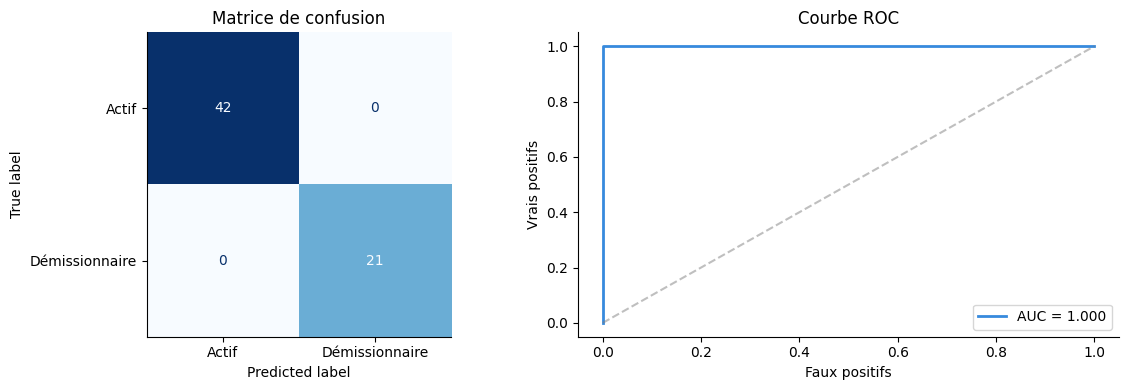

In [12]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print('── Rapport de classification ──────────────────────')
print(classification_report(y_test, y_pred, target_names=['Actif', 'Démissionnaire']))
print(f'AUC-ROC : {roc_auc_score(y_test, y_proba):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['Actif', 'Démissionnaire']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matrice de confusion')

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#378ADD', lw=2,
             label=f'AUC = {roc_auc_score(y_test, y_proba):.3f}')
axes[1].plot([0,1],[0,1],'--', color='gray', alpha=0.5)
axes[1].set_xlabel('Faux positifs'); axes[1].set_ylabel('Vrais positifs')
axes[1].set_title('Courbe ROC'); axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Explicabilité SHAP

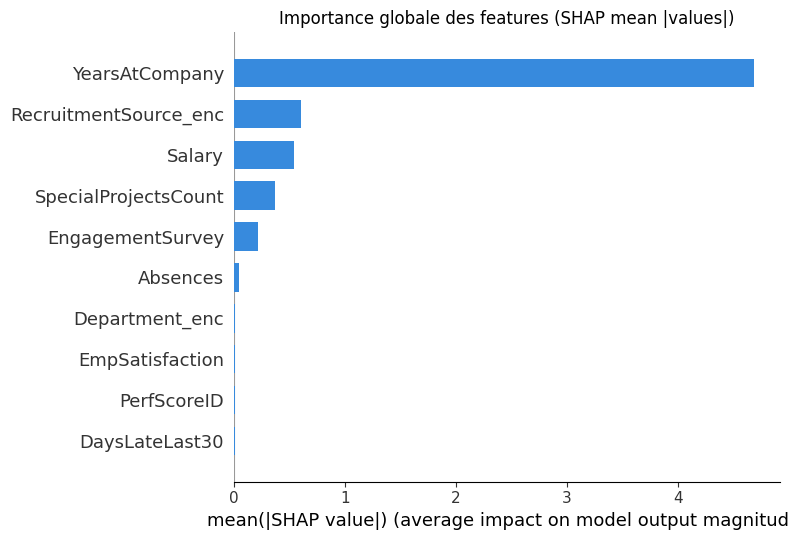

In [13]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES,
                  plot_type='bar', show=False, color='#378ADD')
plt.title('Importance globale des features (SHAP mean |values|)')
plt.tight_layout()
plt.show()

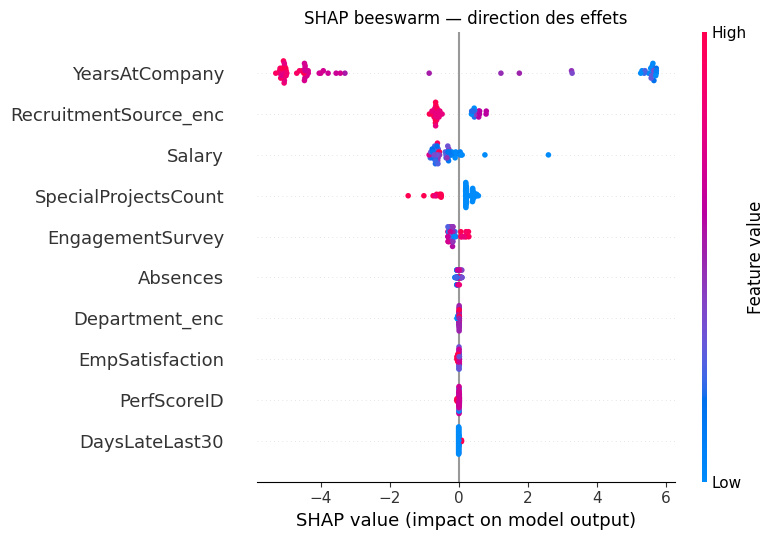

In [14]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False)
plt.title('SHAP beeswarm — direction des effets')
plt.tight_layout()
plt.show()

Employé le plus à risque : EMP_0233 — probabilité de départ : 99.8%


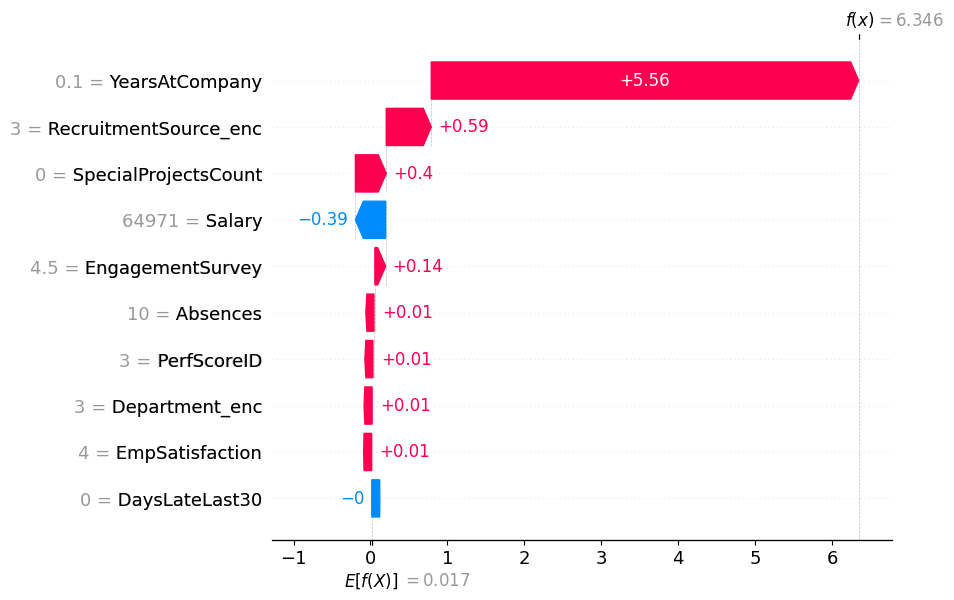

In [15]:

idx_high_risk = y_proba.argmax()
emp_id = df_anon.iloc[X_test.index[idx_high_risk]]['EmpID']
print(f'Employé le plus à risque : {emp_id} — probabilité de départ : {y_proba[idx_high_risk]:.1%}')

shap_exp = shap.Explanation(
    values=shap_values[idx_high_risk],
    base_values=explainer.expected_value,
    data=X_test.iloc[idx_high_risk].values,
    feature_names=FEATURES
)
shap.waterfall_plot(shap_exp, max_display=10)

## 10. Recommandations RH automatiques

In [23]:
"""
def recommend(row, shap_row, features):
    top_idx = np.argsort(np.abs(shap_row))[::-1][:3]
    top_feats = [(features[i], shap_row[i]) for i in top_idx]

    actions = []
    for feat, val in top_feats:
        if 'Salary' in feat and val > 0:
            actions.append('Revalorisation salariale recommandée')
        elif 'Engagement' in feat and val > 0:
            actions.append('Entretien de re-engagement à planifier')
        elif 'Satisfaction' in feat and val > 0:
            actions.append('Enquête satisfaction approfondie')
        elif 'Absences' in feat and val > 0:
            actions.append('Vérifier les causes des absences répétées')
        elif 'DaysLate' in feat and val > 0:
            actions.append('Discuter des contraintes de planning')
        elif 'SpecialProjects' in feat and val > 0:
            actions.append('Proposer un projet stimulant')

    top_labels = [f[0].replace('_enc','') for f in top_feats]
    return {
        'top_factors': ', '.join(top_labels),
        'actions': ' | '.join(actions) if actions else 'Entretien individuel conseillé'
    }

# Dashboard des 10 employés les plus à risque
df_risk = df_audit[df_audit['pred_resign'] == 1].copy()
df_risk = df_risk.sort_values('proba_resign', ascending=False).head(10)

results = []
for idx in df_risk.index:
    test_loc = list(X_test.index).index(idx)
    reco = recommend(df_anon.loc[idx], shap_values[test_loc], FEATURES)
    results.append({
        'EmpID'        : df_anon.loc[idx, 'EmpID'],
        'Position'     : df_anon.loc[idx, 'Position'],
        'Département'  : df_anon.loc[idx, 'Department'],
        'Risque (%)'   : f"{df_risk.loc[idx, 'proba_resign']:.0%}",
        'Top facteurs' : reco['top_factors'],
        'Actions RH'   : reco['actions'],
    })

df_dashboard = pd.DataFrame(results)
print('── Dashboard RH — Employés à risque ──────────────────────────────')
df_dashboard
"""

'\ndef recommend(row, shap_row, features):\n    top_idx = np.argsort(np.abs(shap_row))[::-1][:3]\n    top_feats = [(features[i], shap_row[i]) for i in top_idx]\n\n    actions = []\n    for feat, val in top_feats:\n        if \'Salary\' in feat and val > 0:\n            actions.append(\'Revalorisation salariale recommandée\')\n        elif \'Engagement\' in feat and val > 0:\n            actions.append(\'Entretien de re-engagement à planifier\')\n        elif \'Satisfaction\' in feat and val > 0:\n            actions.append(\'Enquête satisfaction approfondie\')\n        elif \'Absences\' in feat and val > 0:\n            actions.append(\'Vérifier les causes des absences répétées\')\n        elif \'DaysLate\' in feat and val > 0:\n            actions.append(\'Discuter des contraintes de planning\')\n        elif \'SpecialProjects\' in feat and val > 0:\n            actions.append(\'Proposer un projet stimulant\')\n\n    top_labels = [f[0].replace(\'_enc\',\'\') for f in top_feats]\n    r

## 11. IA Frugale — comparaison de modèles

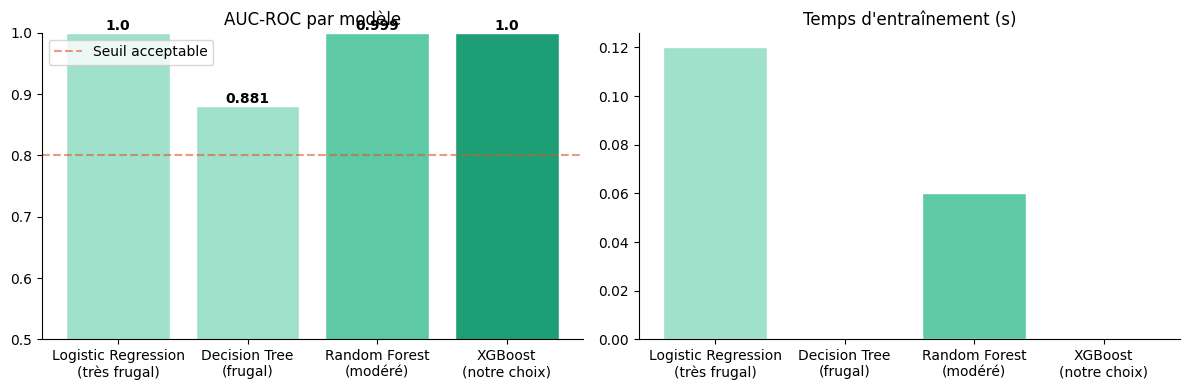

                            Modèle  AUC-ROC  Temps (s)
Logistic Regression\n(très frugal)    1.000       0.12
           Decision Tree\n(frugal)    0.881       0.00
           Random Forest\n(modéré)    0.999       0.06
            XGBoost\n(notre choix)    1.000       0.00

XGBoost offre le meilleur AUC avec un temps raisonnable — choix justifié.


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import time

models_to_compare = {
    'Logistic Regression\n(très frugal)' : LogisticRegression(max_iter=500, random_state=42),
    'Decision Tree\n(frugal)'            : DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest\n(modéré)'            : RandomForestClassifier(n_estimators=50, random_state=42),
    'XGBoost\n(notre choix)'             : model,
}

comparison = []
for name, m in models_to_compare.items():
    t0 = time.time()
    if name != 'XGBoost\n(notre choix)':
        m.fit(X_train_bal, y_train_bal)
    elapsed = time.time() - t0
    auc = roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])
    comparison.append({'Modèle': name, 'AUC-ROC': round(auc, 3),
                       'Temps (s)': round(elapsed, 2)})

df_comp = pd.DataFrame(comparison)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#9FE1CB', '#9FE1CB', '#5DCAA5', '#1D9E75']

axes[0].bar(df_comp['Modèle'], df_comp['AUC-ROC'], color=colors, edgecolor='white')
axes[0].set_ylim(0.5, 1.0)
axes[0].set_title('AUC-ROC par modèle')
axes[0].axhline(0.8, color='#D85A30', linestyle='--', alpha=0.6, label='Seuil acceptable')
axes[0].legend()
for i, v in enumerate(df_comp['AUC-ROC']):
    axes[0].text(i, v + 0.005, str(v), ha='center', fontsize=10, fontweight='bold')

axes[1].bar(df_comp['Modèle'], df_comp['Temps (s)'], color=colors, edgecolor='white')
axes[1].set_title('Temps d\'entraînement (s)')

plt.tight_layout()
plt.show()

print(df_comp.to_string(index=False))
print('\nXGBoost offre le meilleur AUC avec un temps raisonnable — choix justifié.')

## 12. Sauvegarde du modèle et des résultats

In [22]:
"""
import pickle

# Sauvegarde modèle
with open('xgboost_attrition.pkl', 'wb') as f:
    pickle.dump({'model': model, 'features': FEATURES}, f)

# Sauvegarde dashboard
df_dashboard.to_csv('hr_risk_dashboard.csv', index=False)

print('✅ Fichiers sauvegardés :')
print('   xgboost_attrition.pkl    — modèle + features')
print('   hr_dataset_enriched.csv  — dataset anonymisé + textes')
print('   hr_risk_dashboard.csv    — employés à risque + recommandations')
"""

"\nimport pickle\n\n# Sauvegarde modèle\nwith open('xgboost_attrition.pkl', 'wb') as f:\n    pickle.dump({'model': model, 'features': FEATURES}, f)\n\n# Sauvegarde dashboard\ndf_dashboard.to_csv('hr_risk_dashboard.csv', index=False)\n\nprint('✅ Fichiers sauvegardés :')\nprint('   xgboost_attrition.pkl    — modèle + features')\nprint('   hr_dataset_enriched.csv  — dataset anonymisé + textes')\nprint('   hr_risk_dashboard.csv    — employés à risque + recommandations')\n"